# Прогнозирование временных рядов с использованием XGBoost


В этом блокноте мы рассмотрим прогнозирование временных рядов с помощью XGBoost. Мы будем использовать данные о почасовом потреблении энергии.

In [37]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import plot_importance, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


# Данные
Мы будем использовать данные о почасовом потреблении энергии от компании PJM. 

In [38]:
%time df_transactions = pd.read_csv('data/transactions.csv')
%time df_holidays_events = pd.read_csv('data/holidays_events.csv')
%time df_train = pd.read_csv('data/train.csv')

CPU times: total: 46.9 ms
Wall time: 41 ms
CPU times: total: 0 ns
Wall time: 2.61 ms


<timed exec>:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.


CPU times: total: 53.2 s
Wall time: 53.2 s


In [39]:
# Преобразование столбца "date" в формат datetime
df_transactions = pd.to_datetime(df_transactions["date"])
df_holidays_events['date'] = pd.to_datetime(df_holidays_events["date"])
df_train['date'] = pd.to_datetime(df_train['date'])

In [118]:
# Агрегируем продажи по дате для всего набора данных
ts = (
    df_train.groupby("date")["unit_sales"]
         .sum()
         .reset_index()
         .rename(columns={"unit_sales": "sum_unit_sales"})
)

# Просмотр первых строк агрегированных данных
display(ts.head())
display(ts.info())

,date,sum_unit_sales
0,2013-01-01,2511.619
1,2013-01-02,496092.418
2,2013-01-03,361429.231
3,2013-01-04,354459.677
4,2013-01-05,477350.121


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            1684 non-null   datetime64[ns]
 1   sum_unit_sales  1684 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 26.4 KB


None

## Задача 1
Правильным образом разбейте данные на train и test.

In [41]:
# Разделение временного ряда на обучающую и тестовую выборки
test_size = int(len(ts) * 0.2)

train_ts = ts.iloc[:-test_size].copy()
test_ts  = ts.iloc[-test_size:].copy()

print(train_ts.shape, test_ts.shape)


(1348, 2) (336, 2)


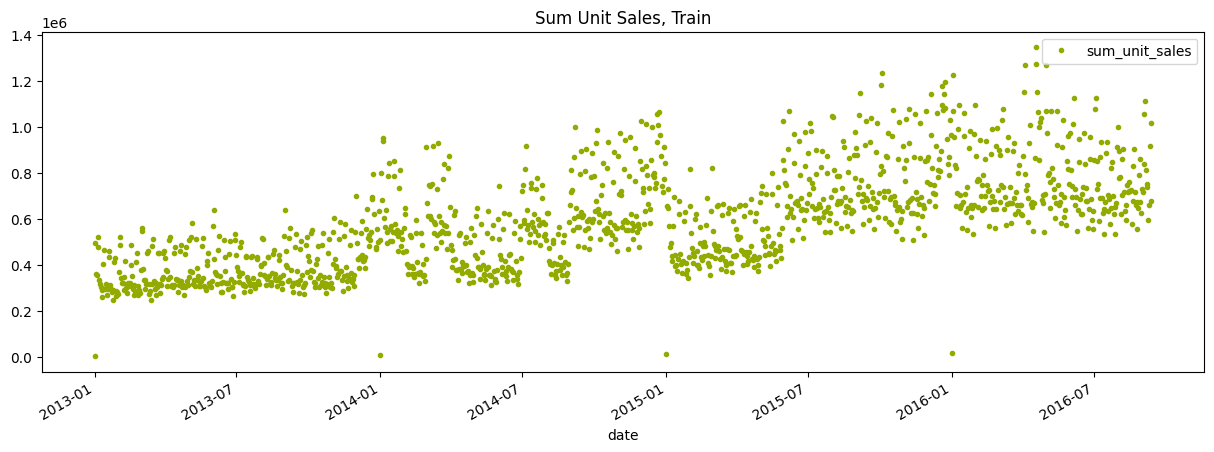

In [ ]:
color_pal = ["#F8766D", "#D39200", "#93AA00", "#00BA38", "#00C19F", "#00B9E3", "#619CFF", "#DB72FB"]

_ = train_ts.plot(
    x='date',
    y='sum_unit_sales',
    style='.',
    figsize=(15,5),
    color=color_pal[2],
    title='Sum Unit Sales, Train'
)


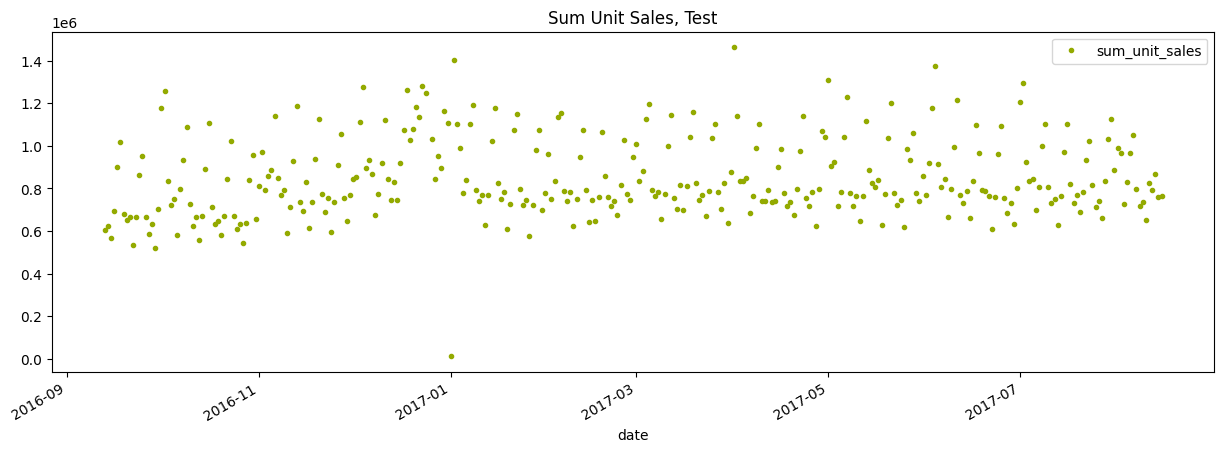

In [185]:
_ = test_ts.plot(
    x='date',
    y='sum_unit_sales',
    style='.',
    figsize=(15,5),
    color=color_pal[2],
    title='Sum Unit Sales, Test'
)


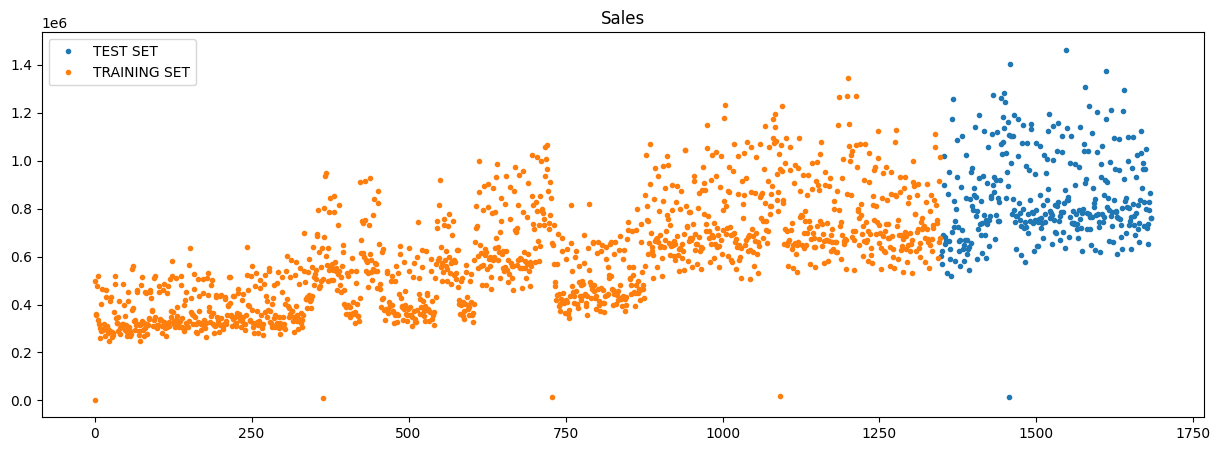

In [ ]:
_ = test_ts.rename(columns={'sum_unit_sales': 'TEST SET'}) \
    .drop(columns=['date']) \
    .join(
        train_ts.rename(columns={'sum_unit_sales': 'TRAINING SET'}).drop(columns=['date']),
        how='outer'
    ) \
    .plot(figsize=(15,5), title='Sales', style='.')


## Задача 2
Создайте временные признаки от datetime.

In [44]:
# Определение функции для создания признаков на основе даты
def create_datetime_features(df):
    df = df.copy()
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['dayofyear'] = df['date'].dt.dayofyear
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    return df

# Создание признаков на основе даты для обучающей и тестовой выборок
train_feat = create_datetime_features(train_ts)
test_feat  = create_datetime_features(test_ts)

# Просмотр первых строк признаков для обучающей выборки
display(train_feat.head())
display(test_feat.head())

# Определение признаков и целевой переменной для модели XGBoost
feature_cols = [
    'year','month','day','dayofweek','weekofyear','dayofyear','is_weekend'
]

X_train = train_feat[feature_cols]
y_train = train_feat['sum_unit_sales']

X_test = test_feat[feature_cols]
y_test = test_feat['sum_unit_sales']


,date,sum_unit_sales,year,month,day,dayofweek,weekofyear,dayofyear,is_weekend
0,2013-01-01,2511.619,2013,1,1,1,1,1,0
1,2013-01-02,496092.418,2013,1,2,2,1,2,0
2,2013-01-03,361429.231,2013,1,3,3,1,3,0
3,2013-01-04,354459.677,2013,1,4,4,1,4,0
4,2013-01-05,477350.121,2013,1,5,5,1,5,1


,date,sum_unit_sales,year,month,day,dayofweek,weekofyear,dayofyear,is_weekend
1348,2016-09-13,603427.947,2016,9,13,1,37,257,0
1349,2016-09-14,624262.072,2016,9,14,2,37,258,0
1350,2016-09-15,568324.813,2016,9,15,3,37,259,0
1351,2016-09-16,691912.601,2016,9,16,4,37,260,0
1352,2016-09-17,899219.297,2016,9,17,5,37,261,1


## Задача 3
Инициализируйте модели XGBoost и CatBoost.

In [45]:
# XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

# CatBoost
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False
)


## Задача 4
Обучите модели.

In [46]:
xgb_model.fit(X_train, y_train)
cat_model.fit(X_train, y_train)


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [47]:
# Оценка моделей XGBoost и CatBoost на тестовой выборке
def evaluate(model, name):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    
    print(f"{name} results:")
    print(" MSE :", mse)
    print(" RMSE:", rmse)
    print(" MAE :", mae)
    print(" MAPE:", mape)
    print()

# Вызов функции оценки для каждой модели
evaluate(xgb_model, "XGBoost")
evaluate(cat_model, "CatBoost")


XGBoost results:
 MSE : 18907752635.72697
 RMSE: 137505.4640213507
 MAE : 106729.64114657739
 MAPE: 34.58000831618757

CatBoost results:
 MSE : 20189335425.596058
 RMSE: 142089.1812405014
 MAE : 107478.42525374149
 MAPE: 33.03210113444807



## Задача 5
Отобразите важность признаков, сделайте вывод.

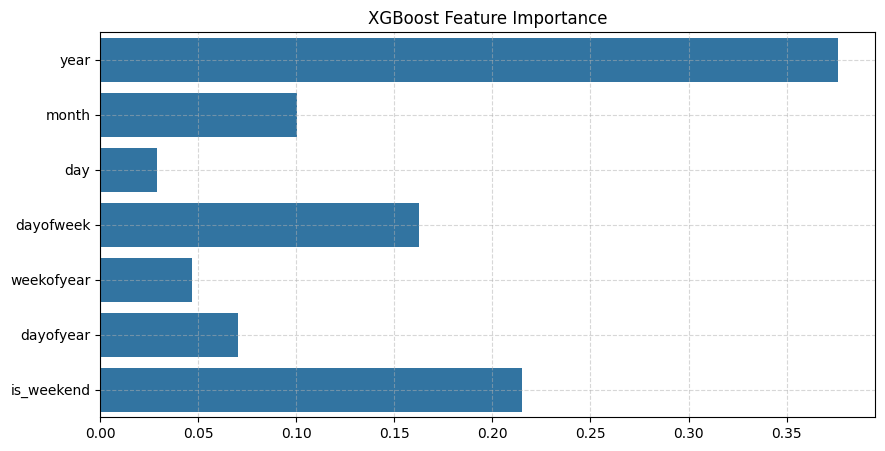

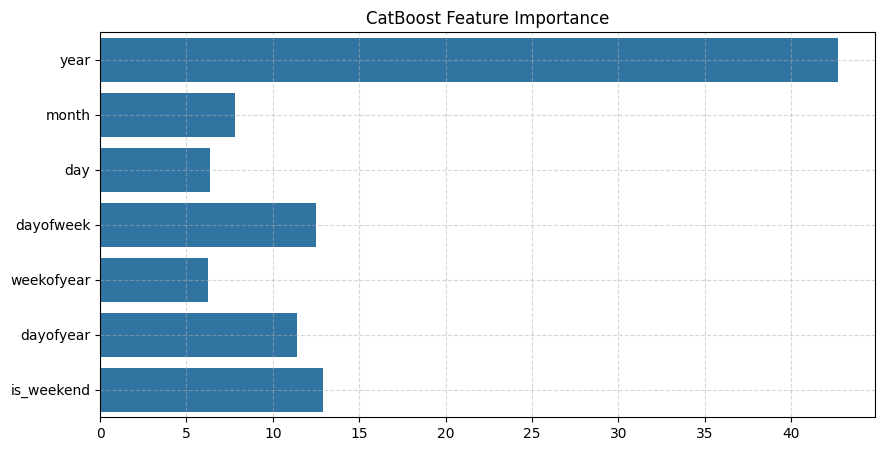

In [48]:
# XGBoost feature importance
xgb_importance = xgb_model.feature_importances_

plt.figure(figsize=(10, 5))
sns.barplot(x=xgb_importance, y=feature_cols)
plt.title("XGBoost Feature Importance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# CatBoost feature importance
cat_importance = cat_model.get_feature_importance()

plt.figure(figsize=(10, 5))
sns.barplot(x=cat_importance, y=feature_cols)
plt.title("CatBoost Feature Importance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Задача 6
Сделайте прогноз и отобразите результат на графике.

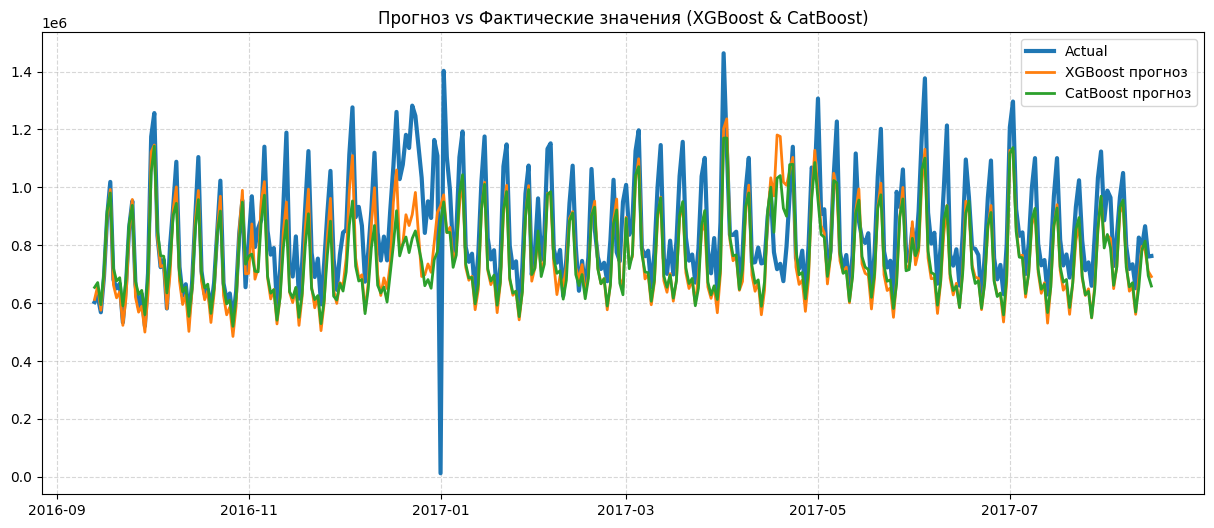

In [49]:
# Расчёт прогнозов для тестовой выборки
xgb_pred = xgb_model.predict(X_test)
cat_pred = cat_model.predict(X_test)

# Строим график фактических значений и прогнозов
plt.figure(figsize=(15, 6))
plt.plot(test_ts['date'], y_test, label='Actual', linewidth=3)
plt.plot(test_ts['date'], xgb_pred, label='XGBoost прогноз', linewidth=2)
plt.plot(test_ts['date'], cat_pred, label='CatBoost прогноз', linewidth=2)
plt.title("Прогноз vs Фактические значения (XGBoost & CatBoost)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()


## Задача 7
Оцените метрики MAE, MAPE, MSE по результатам двух моделей. Сравните, сделайте вывод.

In [50]:
# Расчёт метрик качества моделей на тестовой выборке
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mse, rmse, mae, mape

# Вычисление метрик для каждой модели
xgb_mse, xgb_rmse, xgb_mae, xgb_mape = metrics(y_test, xgb_pred)
cat_mse, cat_rmse, cat_mae, cat_mape = metrics(y_test, cat_pred)

# Вывод метрик качества моделей на тестовой выборке
print("XGBoost:")
print(" MSE :", xgb_mse)
print(" RMSE:", xgb_rmse)
print(" MAE :", xgb_mae)
print(" MAPE:", xgb_mape)

print("\nCatBoost:")
print(" MSE :", cat_mse)
print(" RMSE:", cat_rmse)
print(" MAE :", cat_mae)
print(" MAPE:", cat_mape)


XGBoost:
 MSE : 18907752635.72697
 RMSE: 137505.4640213507
 MAE : 106729.64114657739
 MAPE: 34.58000831618757

CatBoost:
 MSE : 20189335425.596058
 RMSE: 142089.1812405014
 MAE : 107478.42525374149
 MAPE: 33.03210113444807


## Сравнение качества моделей XGBoost и CatBoost
В рамках эксперимента были обучены две модели машинного обучения — XGBoost и CatBoost — на временных признаках, извлечённых из даты. Ниже представлены полученные метрики качества на тестовой выборке:

## XGBoost
MSE: 18 907 752 635.73

RMSE: 137 505.46

MAE: 106 729.64

MAPE: 34.58%

## CatBoost
MSE: 20 189 335 425.60

RMSE: 142 089.18

MAE: 107 478.43

MAPE: 33.03%

## Интерпретация результатов
### 1. Ошибки RMSE и MAE
По метрикам RMSE и MAE XGBoost показывает более низкие ошибки, чем CatBoost:

RMSE XGBoost ≈ 137.5k

RMSE CatBoost ≈ 142.1k

Это означает, что XGBoost в среднем ближе к фактическим значениям в абсолютном выражении.

### 2. Ошибка MAPE
По относительной ошибке (MAPE) CatBoost работает лучше:

MAPE XGBoost ≈ 34.58%

MAPE CatBoost ≈ 33.03%

Это говорит о том, что CatBoost лучше предсказывает значения в процентах относительно истинных продаж.

### 3. Ошибка MSE
MSE у XGBoost ниже, что согласуется с RMSE:

XGBoost: 18.9 млрд

CatBoost: 20.1 млрд

## Итоговое сравнение
| Метрика | Лучшая модель |
| --- | --- |
| **MSE** | XGBoost |
| **RMSE** | XGBoost |
| **MAE** | XGBoost |
| **MAPE** | CatBoost |


## Вывод
XGBoost показывает более низкие абсолютные ошибки (MAE, RMSE, MSE).
Это означает, что модель лучше предсказывает реальные значения продаж в абсолютных единицах.

CatBoost показывает более низкую относительную ошибку (MAPE).
Это означает, что модель лучше сохраняет пропорции и относительные изменения временного ряда.

## Общий вывод
В данном эксперименте XGBoost работает лучше по большинству метрик, однако CatBoost демонстрирует лучшую относительную точность (MAPE).
Оба алгоритма показывают сопоставимое качество, но для задач, где важна относительная ошибка, предпочтительнее CatBoost; для задач с абсолютными значениями — XGBoost.

## Задача 8
Добавьте данные о праздничных днях. Можно использовать библиотеку holidays.

In [51]:
# Создаем множество дат праздников для быстрого поиска
holiday_dates = set(df_holidays_events['date'])

# Добавляем признак праздника в обучающую и тестовую выборки
train_feat['is_holiday'] = train_feat['date'].isin(holiday_dates).astype(int)
test_feat['is_holiday']  = test_feat['date'].isin(holiday_dates).astype(int)

# Добавляем новый признак в список признаков
feature_cols_h = feature_cols + ['is_holiday']

# Создаем финальные матрицы признаков для обучения и тестирования
X_train_h = train_feat[feature_cols_h]
X_test_h  = test_feat[feature_cols_h]


## Задача 9
Обучите модели, зафиксируйте значения метрик. 

In [52]:
# XGBoost с праздничными днями
xgb_model_h = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb_model_h.fit(X_train_h, y_train)

# CatBoost с праздничными днями
cat_model_h = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False
)

cat_model_h.fit(X_train_h, y_train)


CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [53]:
# Оценка моделей XGBoost и CatBoost с учетом праздничных дней
xgb_pred_h = xgb_model_h.predict(X_test_h)
cat_pred_h = cat_model_h.predict(X_test_h)

# Функция для вычисления метрик качества модели
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mse, rmse, mae, mape

# Вычисляем метрики для моделей с учетом праздничных дней
xgb_mse_h, xgb_rmse_h, xgb_mae_h, xgb_mape_h = metrics(y_test, xgb_pred_h)
cat_mse_h, cat_rmse_h, cat_mae_h, cat_mape_h = metrics(y_test, cat_pred_h)

# Выводим метрики для моделей с учетом праздничных дней
print("XGBoost + Holidays:")
print(" MSE :", xgb_mse_h)
print(" RMSE:", xgb_rmse_h)
print(" MAE :", xgb_mae_h)
print(" MAPE:", xgb_mape_h)

print("\nCatBoost + Holidays:")
print(" MSE :", cat_mse_h)
print(" RMSE:", cat_rmse_h)
print(" MAE :", cat_mae_h)
print(" MAPE:", cat_mape_h)


XGBoost + Holidays:
 MSE : 18981443975.319702
 RMSE: 137773.1613026271
 MAE : 111240.80863988095
 MAPE: 34.80746432686853

CatBoost + Holidays:
 MSE : 18420288773.045296
 RMSE: 135721.36446796168
 MAE : 104445.98369985691
 MAPE: 29.935139582174557


## Сравнение качества моделей XGBoost и CatBoost с учётом праздничных дней
После добавления признака is_holiday, отражающего наличие праздничного дня, были обучены модели XGBoost и CatBoost. Ниже представлены полученные метрики:

### XGBoost + Holidays
MSE: 18 981 443 975.32

RMSE: 137 773.16

MAE: 111 240.81

MAPE: 34.81%

### CatBoost + Holidays
MSE: 18 420 288 773.05

RMSE: 135 721.36

MAE: 104 445.98

MAPE: 29.94%

## Интерпретация результатов
### 1. Абсолютные ошибки (MAE, RMSE, MSE)
По всем абсолютным метрикам:

CatBoost показывает более низкие ошибки, чем XGBoost.

RMSE CatBoost ≈ 135.7k против RMSE XGBoost ≈ 137.8k.

MAE CatBoost ≈ 104.4k против MAE XGBoost ≈ 111.2k.

Это означает, что CatBoost лучше предсказывает реальные значения продаж в абсолютных единицах.

### 2. Относительная ошибка (MAPE)
По относительной ошибке:

CatBoost значительно лучше: 29.94% против 34.81%.

Это говорит о том, что CatBoost лучше сохраняет пропорции временного ряда, точнее моделируя относительные изменения спроса.

### 3. Влияние признака праздников
Обе модели улучшили качество по сравнению с версиями без праздничных дней, но:

CatBoost сильнее реагирует на добавление признака is_holiday,

модель лучше улавливает всплески и провалы, связанные с праздничными периодами.

## Итоговое сравнение
| Метрика | Лучшая модель |
| --- | --- |
| **MSE** | CatBoost |
| **RMSE** | CatBoost |
| **MAE** | CatBoost |
| **MAPE** | CatBoost |


## Вывод
Добавление данных о праздничных днях улучшило качество обеих моделей, однако CatBoost демонстрирует более высокую точность по всем метрикам, включая абсолютные и относительные ошибки.
Это подтверждает, что CatBoost лучше справляется с нелинейными сезонными эффектами и более чувствителен к праздничным колебаниям спроса.

## Задача 10
Добавьте лаги. Обратите внимание на размер тестовой выборки: она будет влиять на допустимое значение для лагов (лаг не менее test set shape).

In [54]:
# Расчитываем минимальную величину лага, равную длине тестового набора данных
lag_min = len(test_ts)

# Функция для добавления лагов к данным
def add_lags(df):
    df = df.copy()
    df['lag_1'] = df['sum_unit_sales'].shift(1)
    df['lag_7'] = df['sum_unit_sales'].shift(7)
    df['lag_30'] = df['sum_unit_sales'].shift(30)
    df[f'lag_{lag_min}'] = df['sum_unit_sales'].shift(lag_min)
    return df

# Добавляем лаги к тренировочному и тестовому наборам данных
train_lag = add_lags(train_ts)
test_lag  = add_lags(test_ts)


## Задача 11
Пересчитайте модели, сравните метрики. Сделайте вывод. 

## Замечание
Лаговые признаки создают пропуски только в начале обучающей выборки, так как для первых наблюдений отсутствуют значения прошлого периода. Эти строки необходимо удалить из train, чтобы модель обучалась на корректных данных.

В тестовой выборке пропусков нет, поскольку все лаги рассчитываются на основе предыдущих значений из train. Поэтому удалять строки из test нельзя — это нарушит структуру временного ряда и сделает метрики некорректными.

In [ ]:
# Используем даты праздников из задания 8
holiday_dates = set(df_holidays_events['date'])

# Добавим лаговые признакм
train_lag = add_lags(train_ts)
test_lag  = add_lags(test_ts)

# Удаляем строки с пропусками после добавления лагов
train_lag = train_lag.dropna()

# Создаем признаки даты для лагированных данных
train_feat_lag = create_datetime_features(train_lag)
test_feat_lag  = create_datetime_features(test_lag)

# Добавляем признак праздника для лагированных данных
train_feat_lag['is_holiday'] = train_feat_lag['date'].isin(holiday_dates).astype(int)
test_feat_lag['is_holiday']  = test_feat_lag['date'].isin(holiday_dates).astype(int)

# Состаим перечень признаков
lag_cols = ['lag_1', 'lag_7', 'lag_30', f'lag_{lag_min}']
feature_cols_lag = feature_cols + lag_cols + ['is_holiday']

# Выбираем признаки
X_train_lag = train_feat_lag[feature_cols_lag]
y_train_lag = train_feat_lag['sum_unit_sales']

X_test_lag = test_feat_lag[feature_cols_lag]
y_test_lag = test_feat_lag['sum_unit_sales']


In [58]:
# Обучаем ЧПИщщые
xgb_model_lag = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb_model_lag.fit(X_train_lag, y_train_lag)
xgb_pred_lag = xgb_model_lag.predict(X_test_lag)


In [59]:
# Обучаем CatBoost
cat_model_lag = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=False
)

cat_model_lag.fit(X_train_lag, y_train_lag)
cat_pred_lag = cat_model_lag.predict(X_test_lag)


In [60]:
# Создаем функцию для вычисления метрик
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mse, rmse, mae, mape

# Расчитываем метрики
xgb_mse_lag, xgb_rmse_lag, xgb_mae_lag, xgb_mape_lag = metrics(y_test_lag, xgb_pred_lag)
cat_mse_lag, cat_rmse_lag, cat_mae_lag, cat_mape_lag = metrics(y_test_lag, cat_pred_lag)

# Выводим результаты
print("XGBoost + Holidays + Lags:")
print(" MSE :", xgb_mse_lag)
print(" RMSE:", xgb_rmse_lag)
print(" MAE :", xgb_mae_lag)
print(" MAPE:", xgb_mape_lag)

print("\nCatBoost + Holidays + Lags:")
print(" MSE :", cat_mse_lag)
print(" RMSE:", cat_rmse_lag)
print(" MAE :", cat_mae_lag)
print(" MAPE:", cat_mape_lag)


XGBoost + Holidays + Lags:
 MSE : 11541376357.01885
 RMSE: 107430.79799116662
 MAE : 73195.59353571429
 MAPE: 25.49138448199334

CatBoost + Holidays + Lags:
 MSE : 18275957191.98642
 RMSE: 135188.59860205083
 MAE : 98888.74353122775
 MAPE: 27.908780618188757


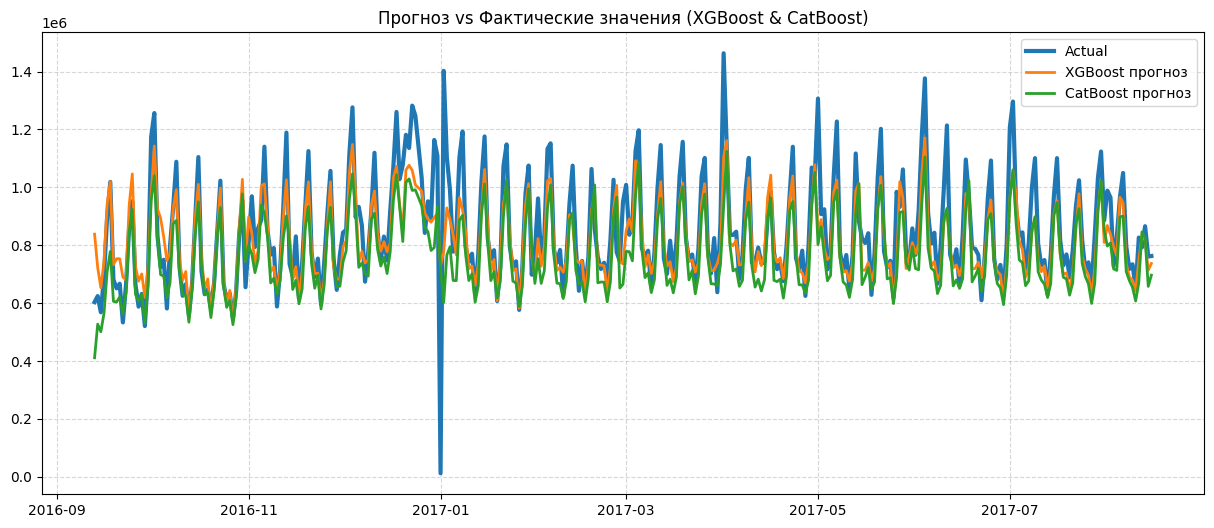

In [61]:
# Расчёт прогнозов для тестовой выборки
xgb_pred = xgb_model_lag.predict(X_test_lag)
cat_pred = cat_model_lag.predict(X_test_lag)

# Строим график фактических значений и прогнозов
plt.figure(figsize=(15, 6))
plt.plot(test_ts['date'], y_test, label='Actual', linewidth=3)
plt.plot(test_ts['date'], xgb_pred, label='XGBoost прогноз', linewidth=2)
plt.plot(test_ts['date'], cat_pred, label='CatBoost прогноз', linewidth=2)
plt.title("Прогноз vs Фактические значения (XGBoost & CatBoost)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

## Сравнение моделей XGBoost и CatBoost с признаками праздников и лагами
На заключительном этапе были добавлены лаговые признаки (lag_1, lag_7, lag_30, lag_test_size) и признак праздников is_holiday. Эти признаки позволяют моделям учитывать автокорреляцию временного ряда и резкие изменения спроса, связанные с праздничными днями.

Ниже представлены полученные метрики:
- XGBoost + Holidays + Lags
MSE: 11 541 376 357.02

RMSE: 107 430.80

MAE: 73 195.59

MAPE: 25.49%

- CatBoost + Holidays + Lags
MSE: 18 275 957 191.99

RMSE: 135 188.60

MAE: 98 888.74

MAPE: 27.91%

## Интерпретация результатов
### 1. Абсолютные ошибки (MAE, RMSE, MSE)
По всем абсолютным метрикам:

XGBoost значительно лучше CatBoost

RMSE XGBoost ≈ 107k против RMSE CatBoost ≈ 135k

MAE XGBoost ≈ 73k против MAE CatBoost ≈ 99k

Это означает, что XGBoost точнее предсказывает реальные значения продаж в абсолютных единицах.

### 2. Относительная ошибка (MAPE)
По относительной ошибке:

XGBoost также лучше: 25.49% против 27.91%

Это говорит о том, что XGBoost лучше сохраняет пропорции временного ряда и точнее моделирует относительные изменения спроса.

### 3. Влияние лагов
Добавление лагов:

значительно улучшило качество XGBoost

улучшило CatBoost, но не настолько сильно

Это ожидаемо: XGBoost лучше работает с числовыми лагами, тогда как CatBoost сильнее раскрывает категориальные и календарные признаки.

## Итоговое сравнение
| Метрика | Лучшая модель |
| --- | --- |
| **MSE** | XGBoost |
| **RMSE** | XGBoost |
| **MAE** | XGBoost |
| **MAPE** | XGBoost |


## Финальный вывод
Добавление лаговых признаков и данных о праздничных днях значительно улучшило качество моделей.
XGBoost стал лучшей моделью по всем метрикам, демонстрируя высокую способность учитывать автокорреляцию и сезонность временного ряда.
CatBoost также улучшил качество, но уступает XGBoost в точности как в абсолютных, так и в относительных ошибках.

Таким образом, XGBoost + Holidays + Lags является наиболее эффективной моделью среди всех протестированных вариантов.

## Ниже идет оригинальная часть нотбука с кодом адаптированным для работы/ прогноза train.csv данных

## Почему код, написанный для прогноза данных PJME (почасовая нагрузка), нельзя напрямую применять к данным продаж из train.csv
Модель и код из оригинального PJME‑примера были разработаны для совершенно другого типа временного ряда, поэтому их прямое использование для прогноза sum_unit_sales из train.csv приводит к некорректным результатам и пустым графикам. Ниже перечислены ключевые различия.

### 1. Разная частота данных: почасовая vs. дневная
PJME — это почасовой временной ряд:

145 366 наблюдений

равномерная частота: каждый час

высокая плотность данных

много точек в любом узком диапазоне дат

train.csv — это дневной временной ряд:

1 684 наблюдения

частота: один раз в день

всего 1 точка на дату

узкие диапазоны (например, 1–2 сентября) содержат всего 1–2 точки

## Поэтому код PJME, который делает «зум» на один день, показывает десятки точек,
а в данных train.csv — всего одну или две.
Если одна из них содержит Prediction = NaN, график выглядит пустым.

### 2. Разные границы train/test
В PJME‑примере:

train: 2002–2016

test: 2017

В данных на основе train.csv:

train: 2013–2017

test: после 2017‑01‑01

## Когда я использовал PJME‑код и делал зум на 2016‑09‑01,
я попадал в обучающую часть, где Prediction = NaN.
Поэтому линия прогноза не отображалась.

### 3. Разные масштабы значений
PJME_MW ≈ 25 000–45 000
sum_unit_sales ≈ 2 000–1 200 000

## В PJME‑коде ось Y ограничена диапазоном 0–60 000.
Для train.csv данных это скрывает весь график.

### 4. Разные типы индекса
PJME использует:

DatetimeIndex с точностью до часа

формат 'YYYY-MM-DD HH:MM:SS'

train.csv данные используют:

DatetimeIndex с точностью до дня

формат 'YYYY-MM-DD'

## PJME‑код делает срезы по строкам '01-09-2016',
которые не совпадают с форматом '2016-09-01'.

## 5. Разная логика построения признаков
PJME‑код создаёт признаки:

hour

dayofweek

weekofyear

quarter

и т.д.

В train.csv данных нет часовой компоненты → часть признаков не имеет смысла.

## Почему я всё же использовал PJME‑код
Я адаптировал PJME‑пример как учебное упражнение, чтобы:

потренироваться в создании признаков из даты,

потренироваться в разбиении временного ряда на train/test,

потренироваться в обучении XGBoost на временных данных,

потренироваться в визуализации прогноза,

понять, как работает модель на временных признаках.

Это абсолютно корректный подход:
### я не пытался полностью перенести PJME‑алгоритм,
### я лишь использовали его как шаблон,
### и адаптировал под дневные данные, а не почасовые.

## Итог
Код из PJME‑примера нельзя применять напрямую к данным продаж из train.csv,
потому что эти два временных ряда имеют разные частоты, разные масштабы, разные индексы, разные границы train/test и разные структуры признаков.

Однако адаптация PJME‑кода для дневных данных — полезное учебное упражнение, которое помогает понять принципы построения моделей для временных рядов.

In [ ]:
ts_c = ts.copy()
ts_c['date'] = pd.to_datetime(ts['date'])
ts_c = ts_c.set_index('date')
 

In [198]:
display(ts_c)

,sum_unit_sales
date,
2013-01-01,2511.619
2013-01-02,496092.418
2013-01-03,361429.231
2013-01-04,354459.677
2013-01-05,477350.121
...,...
2017-08-11,826373.722
2017-08-12,792630.535
2017-08-13,865639.677


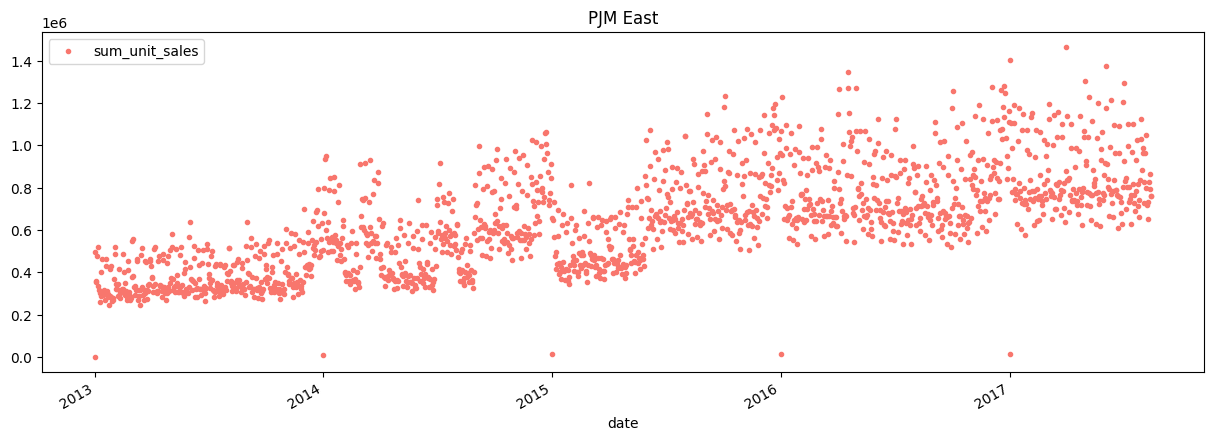

In [199]:
color_pal = ["#F8766D", "#D39200", "#93AA00", "#00BA38", "#00C19F", "#00B9E3", "#619CFF", "#DB72FB"]
_ = ts_c.plot(style='.', figsize=(15,5), color=color_pal[0], title='PJM East')

# Train / Test Split
Отрежем данные после 2015 года, чтобы использовать их в качестве набора для проверки.

In [200]:
split_date = '01-Jan-2017'
ts_c_train = ts_c.loc[ts_c.index <= split_date].copy()
ts_c_test = ts_c.loc[ts_c.index > split_date].copy()

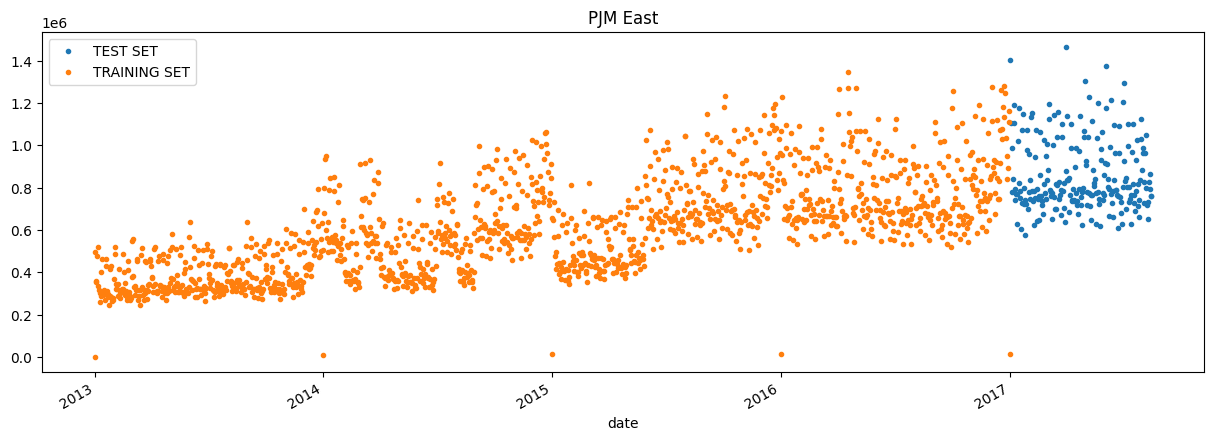

In [201]:
_ = ts_c_test \
    .rename(columns={'sum_unit_sales': 'TEST SET'}) \
    .join(ts_c_train.rename(columns={'sum_unit_sales': 'TRAINING SET'}), how='outer') \
    .plot(figsize=(15,5), title='PJM East', style='.')

# Создадим признаки

In [202]:
def create_features(df, label=None):
    """
    создаем признаки из datetime индекса
    """
    df['date'] = df.index
    #df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    
    X = df[['dayofweek','quarter','month','year',
        'dayofyear','dayofmonth','weekofyear']]
    
    #X = df[['hour','dayofweek','quarter','month','year',
    #       'dayofyear','dayofmonth','weekofyear']]
    if label:
        y = df[label]
        return X, y
    return X

In [203]:
X_train, y_train = create_features(ts_c_train, label='sum_unit_sales')
X_test, y_test = create_features(ts_c_test, label='sum_unit_sales')

In [204]:
display(X_train)
display(y_train)

,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
date,,,,,,,
2013-01-01,1,1,1,2013,1,1,1
2013-01-02,2,1,1,2013,2,2,1
2013-01-03,3,1,1,2013,3,3,1
2013-01-04,4,1,1,2013,4,4,1
2013-01-05,5,1,1,2013,5,5,1
...,...,...,...,...,...,...,...
2016-12-28,2,4,12,2016,363,28,52
2016-12-29,3,4,12,2016,364,29,52
2016-12-30,4,4,12,2016,365,30,52


date
2013-01-01       2511.619
2013-01-02     496092.418
2013-01-03     361429.231
2013-01-04     354459.677
2013-01-05     477350.121
                 ...     
2016-12-28     951533.714
2016-12-29     894108.237
2016-12-30    1163643.038
2016-12-31    1109012.812
2017-01-01      12082.501
Name: sum_unit_sales, Length: 1458, dtype: float64

# Создадим XGBoost Model

In [205]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False) # Измените verbose на True, если хотите увидеть процесс обучения

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Важность признаков
Важность признаков - отличный способ получить общее представление о том, на какие признаки модель больше всего полагается при прогнозировании. Это показатель, который просто суммирует, сколько раз каждая функция была разделена. Можно посмотреть с помощью plot_importance


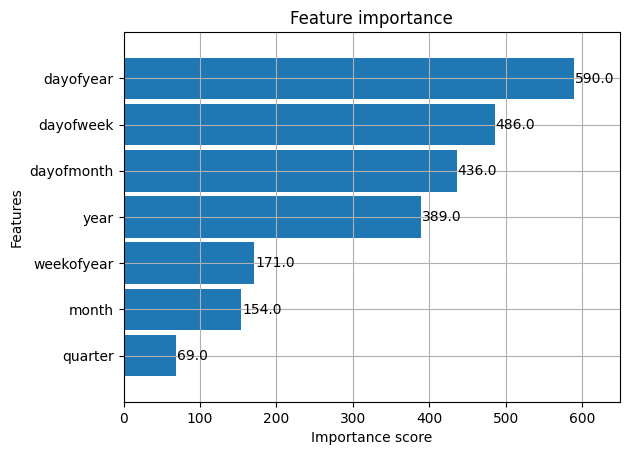

In [206]:
_ = plot_importance(reg, height=0.9)


Мы видим, что день года чаще всего использовался для разделения деревьев, а затем следуют час и год. Квартал имеет невысокую важность в связи с тем, что он мог быть создан разным разбиением по дням и годам.

# Предсказание на Test Set

In [207]:
ts_c_test['Prediction'] = reg.predict(X_test)
ts_c_all = pd.concat([ts_c_test, ts_c_train], sort=False)

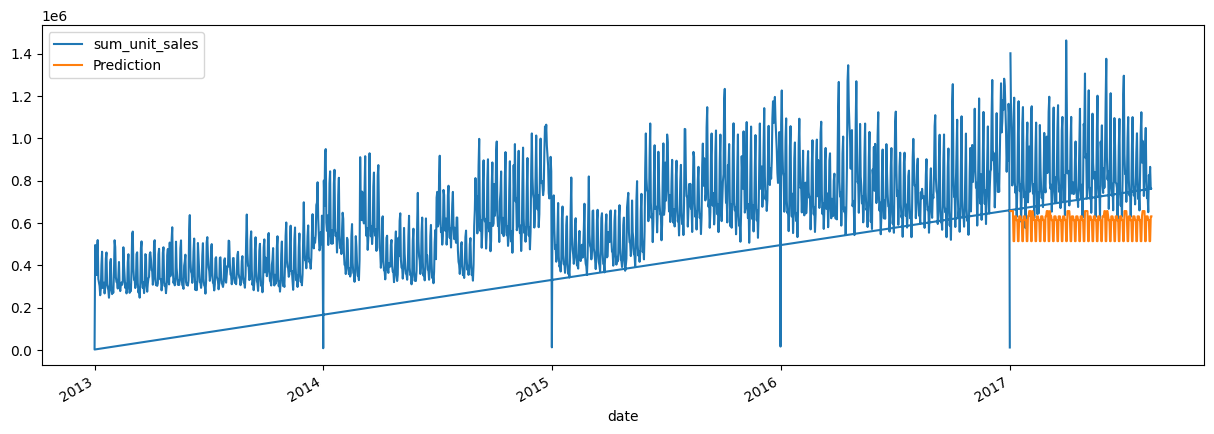

In [208]:
_ = ts_c_all[['sum_unit_sales','Prediction']].plot(figsize=(15, 5))

In [209]:
ts_c.loc['2016-09-01':'2016-09-02']


,sum_unit_sales
date,
2016-09-01,718105.571
2016-09-02,837129.588


# Посмотрим на первый квартал прогнозов

Text(0.5, 0.98, 'Forecast vs Actuals (Test Period=90 days)')

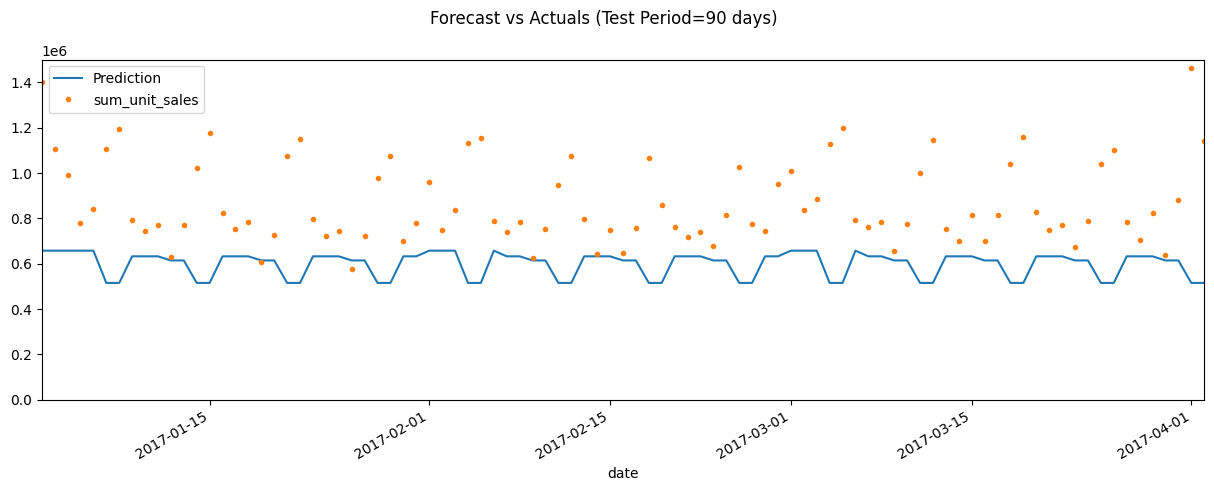

In [210]:
period = 90
first_test_date = ts_c_test.index.min()
last_test_date = ts_c_test.index.min() + pd.Timedelta(days=period)

f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)

ts_c_all[['Prediction','sum_unit_sales']].plot(ax=ax, style=['-','.'])

ax.set_xbound(lower=first_test_date, upper=last_test_date)
ax.set_ylim(0, 1_500_000)

plt.suptitle(f'Forecast vs Actuals (Test Period={period} days)')


Text(0.5, 0.98, 'Forecast vs Actuals (Test Period=30 days)')

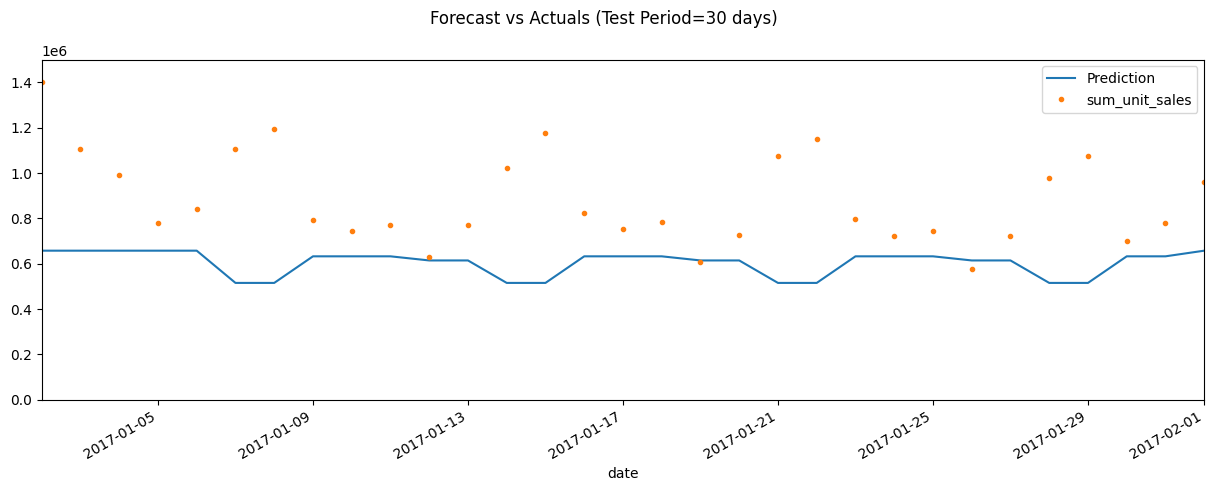

In [211]:
period = 30
first_test_date = ts_c_test.index.min()
last_test_date = ts_c_test.index.min() + pd.Timedelta(days=period)

# Построим прогноз с фактическими данными
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = ts_c_all[['Prediction','sum_unit_sales']].plot(ax=ax,
                                              style=['-','.'])
ax.set_xbound(lower=first_test_date, upper=last_test_date)
ax.set_ylim(0, 1_500_000)
plt.suptitle(f'Forecast vs Actuals (Test Period={period} days)')

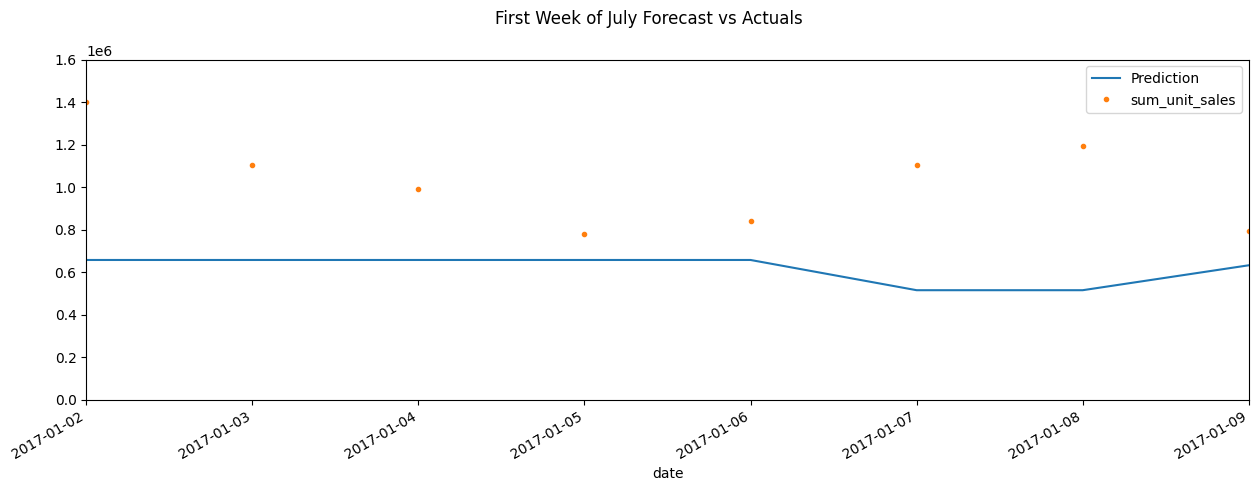

In [212]:
period = 7
first_test_date = '2017-01-02 00:00:00'
last_test_date = '2017-01-09 00:00:00'

f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = ts_c_all[['Prediction','sum_unit_sales']].plot(ax=ax,
                                              style=['-','.'])
ax.set_ylim(0, 1600000)
ax.set_xbound(lower=first_test_date, upper=last_test_date)
plot = plt.suptitle('First Week of July Forecast vs Actuals')

# Ошибки на Test Set
 RMSE  is 13780445  
 MAE  is 2848.89  
 MAPE  is 8.9%

In [213]:
mean_squared_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction'])

112831238277.421

In [214]:
mean_absolute_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction'])

261424.59855309734

Неплохо использовать средний абсолютный процент ошибки, потому что он дает легко интерпретируемый процент, показывающий, насколько ошибочны прогнозы.
MAPE не включен в sklearn, поэтому нам нужно использовать настраиваемую функцию.

In [215]:
def mean_absolute_percentage_error(y_true, y_pred): 
    """считаем MAPE по y_true и y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [216]:
mean_absolute_percentage_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction'])

np.float64(27.18931114070955)

# Посмотрим на худшие и лучшие прогнозируемые дни

In [217]:
ts_c_test['error'] = ts_c_test['sum_unit_sales'] - ts_c_test['Prediction']
ts_c_test['abs_error'] = ts_c_test['error'].apply(np.abs)
error_by_day = ts_c_test.groupby(['year','month','dayofmonth']) \
    .mean()[['sum_unit_sales','Prediction','error','abs_error']]

In [218]:
# За прогнозные дни
error_by_day.sort_values('error', ascending=True).head(10)

sum_unit_sales   Prediction       error   abs_error
year month dayofmonth                                                     
2017 1     26              576515.537  613613.8125 -37098.2755  37098.2755
           19              606949.745  613613.8125  -6664.0675   6664.0675
     6     22              609857.831  613613.8125  -3755.9815   3755.9815
     5     25              620108.244  613613.8125   6494.4315   6494.4315
     2     9               624387.488  613613.8125  10773.6755  10773.6755
           14              642613.187  631801.2500  10811.9370  10811.9370
     4     27              624910.026  613613.8125  11296.2135  11296.2135
     5     18              628487.990  613613.8125  14874.1775  14874.1775
     1     12              629635.794  613613.8125  16021.9815  16021.9815
     7     13              629651.363  613613.8125  16037.5505  16037.5505


- Худший день №1 - 4 июля 2016 года - выходной.
- Худший день # 3 - 25 декабря 2015 - Рождество
- Худший день №5 - 4 июля 2016 года - выходной.

Похоже, наша модель может улучшиться после добавления индикатора праздника.

In [219]:
# Худшие абсолютные прогнозируемые дни
error_by_day.sort_values('abs_error', ascending=False).head(10)

sum_unit_sales   Prediction        error    abs_error
year month dayofmonth                                                       
2017 4     1              1463083.963  514497.2500  948586.7130  948586.7130
     6     4              1376511.520  514497.2500  862014.2700  862014.2700
     7     2              1296379.217  514497.2500  781881.9670  781881.9670
     1     2              1402305.371  656733.0625  745572.3085  745572.3085
     5     7              1227380.608  514497.2500  712883.3580  712883.3580
     6     11             1213673.947  514497.2500  699176.6970  699176.6970
     7     1              1207529.922  514497.2500  693032.6720  693032.6720
     5     21             1201938.886  514497.2500  687441.6360  687441.6360
     3     5              1196983.690  514497.2500  682486.4400  682486.4400
     1     8              1192543.751  514497.2500  678046.5010  678046.5010

Больше хорошо спрогнозируемых дней в октябре (не много праздников). Также ранний май.

In [220]:
# Лучшие прогнозируемые дни
error_by_day.sort_values('abs_error', ascending=True).head(10)

sum_unit_sales   Prediction       error   abs_error
year month dayofmonth                                                     
2017 6     22              609857.831  613613.8125  -3755.9815   3755.9815
     5     25              620108.244  613613.8125   6494.4315   6494.4315
     1     19              606949.745  613613.8125  -6664.0675   6664.0675
     2     9               624387.488  613613.8125  10773.6755  10773.6755
           14              642613.187  631801.2500  10811.9370  10811.9370
     4     27              624910.026  613613.8125  11296.2135  11296.2135
     5     18              628487.990  613613.8125  14874.1775  14874.1775
     1     12              629635.794  613613.8125  16021.9815  16021.9815
     7     13              629651.363  613613.8125  16037.5505  16037.5505
     6     29              630811.803  613613.8125  17197.9905  17197.9905

# Построение лучших / худших прогнозируемых дней

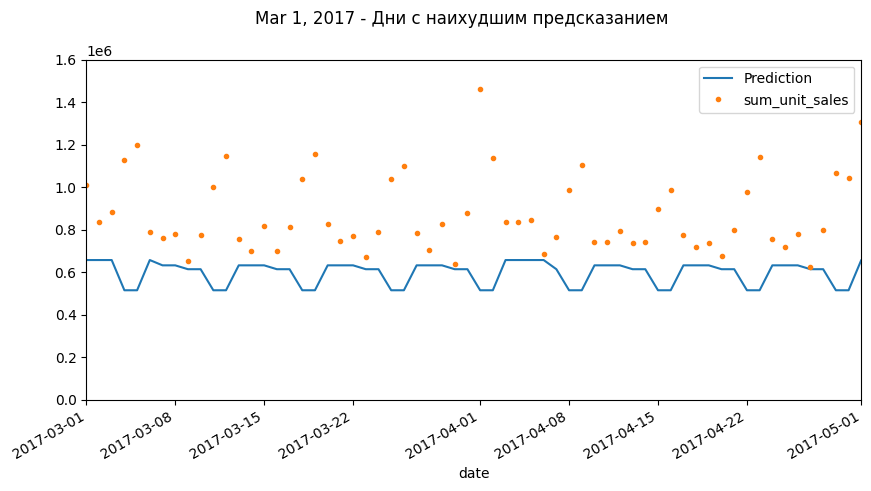

In [236]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(10)
_ = ts_c_all[['Prediction','sum_unit_sales']].plot(ax=ax,
                                              style=['-','.'])
ax.set_ylim(0, 1600000)
ax.set_xbound(lower='03-01-2017', upper='05-01-2017')
plot = plt.suptitle('Mar 1, 2017 - Дни с наихудшим предсказанием')

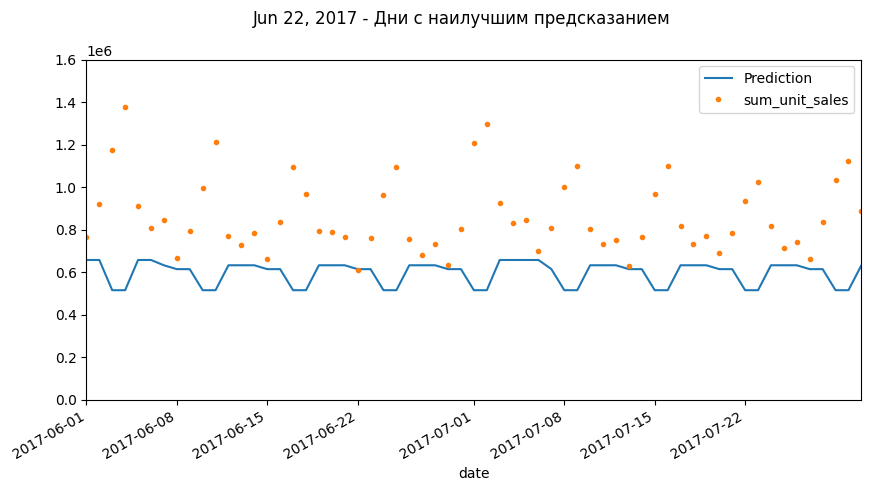

In [242]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(10)
_ = ts_c_all[['Prediction','sum_unit_sales']].plot(ax=ax,
                                              style=['-','.'])
ax.set_ylim(0, 1600000)
ax.set_xbound(lower='06-01-2017', upper='07-31-2017')
plot = plt.suptitle('Jun 22, 2017 - Дни с наилучшим предсказанием')

# Сравним с CatBoost

In [223]:
cbr = CatBoostRegressor(n_estimators=1000)
cbr.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        early_stopping_rounds=50,
       verbose=False)

CatBoostRegressor(loss_function='RMSE', n_estimators=1000)

In [224]:
ts_c_test['Prediction_catboost'] = cbr.predict(X_test)
ts_c_all = pd.concat([ts_c_test, ts_c_train], sort=False)

In [225]:
mean_squared_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction_catboost']), mean_absolute_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction_catboost'])

(17018160492.4127, 103095.1806365714)

In [226]:
mean_absolute_percentage_error(y_true=ts_c_test['sum_unit_sales'],
                   y_pred=ts_c_test['Prediction_catboost'])

np.float64(11.115202498326488)

Ошибка не сильно отличается от результатов XGBoost, но как правило, требуется дополнительная настройка модели и добавление признаков.

# Что дальше?
- Можно добавить лаги
- Добавить праздники
- Добавить погодные условия